In [17]:
import numpy as np
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sksurv.metrics import integrated_brier_score, brier_score
from sklearn.model_selection import train_test_split
from lifelines.utils import concordance_index

In [18]:
df_improvement = pd.read_csv("dataset/df_clean.csv")

# Although XGBoost doesn't need scaled inputs, put it anyways to ensure fairness for comparison between baseline and improved model
df_improvement["Minutes of Use"] = df_improvement["Seconds of Use"] / 60
df_improvement = df_improvement.drop(columns=["Seconds of Use"])

print(f"Shape: {df_improvement.shape}")

# Train/val/test split is 70/15/15 to not deprive the model from data shortage for training
df_study, df_test = train_test_split(df_improvement, test_size=0.15, stratify=df_improvement['Churn'], random_state=42)
df_train, df_val = train_test_split(df_study, test_size=0.1765, stratify=df_study['Churn'], random_state=42) # 0.1765 is from 15 / 85 (85 from df_study)
print(f"Shape for training set: {df_train.shape}")
print(f"Shape for validation set: {df_val.shape}")
print(f"Shape for test set: {df_test.shape}")

Shape: (2850, 14)
Shape for training set: (1994, 14)
Shape for validation set: (428, 14)
Shape for test set: (428, 14)


In [19]:
df_train.to_csv("dataset/df_train.csv", index=False)
df_val.to_csv("dataset/df_val.csv", index=False)
df_test.to_csv("dataset/df_test.csv", index=False)

In [20]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [21]:
drop_columns = ["Subscription Length", "Churn", "Status", "Customer Value", "Age"]

In [22]:
models = []
parameters = {
    'objective': 'survival:aft',
    'eval_metric': 'aft-nloglik',
    'aft_loss_distribution': 'normal',
    'learning_rate': 0.01,
    'max_depth': 8,
    'min_child_weight': 10
}

# The paramaters are picked from Random Search, Random Search is used because it's more computationally efficient than Grid Search
# And it experiments a broader range of values of each hyperparameter 
# rather than keep on testing the same significant parameter with different values of insignificant ones (Grid Search does that)

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train["Churn"])): 
   
    train_fold = df_train.iloc[train_idx]
    val_fold = df_train.iloc[val_idx]

   
   # Drop the targets for X to prevent data leakage 
    X_train = df_train.drop(columns=drop_columns)

    # DMatrix just makes the XGB perform faster later during training
    dtrain = xgb.DMatrix(X_train)

    # We know that no customers churned before the end of their Subscription Length
    y_lower_bound = df_train['Subscription Length'].values

    # Let's say if the result is positive, the model knows the customer will churn eventually, 
    # but in the meantime, assume they churn between month of their subs length and month infinity or forever
    y_upper_bound = np.where(df_train['Churn'] == 0, np.inf, df_train['Subscription Length'].values)

    dtrain.set_float_info('label_lower_bound', y_lower_bound)
    dtrain.set_float_info('label_upper_bound', y_upper_bound)

    X_val = df_val.drop(columns=drop_columns)
    dval = xgb.DMatrix(X_val)

    y_lower_val = df_val['Subscription Length'].values
    y_upper_val = np.where(df_val['Churn'] == 0, np.inf, df_val['Subscription Length'].values)

    dval.set_float_info('label_lower_bound', y_lower_val)
    dval.set_float_info('label_upper_bound', y_upper_val)
    
    evals = [(dtrain, 'train'), (dval, 'val')]

    xgb_model = xgb.train(
        params=parameters, 
        dtrain=dtrain, 
        num_boost_round=500, 
        evals=evals, 
        early_stopping_rounds=20,
        verbose_eval=10  
    )
    models.append(xgb_model)


[0]	train-aft-nloglik:11.02219	val-aft-nloglik:11.04489


[10]	train-aft-nloglik:9.30039	val-aft-nloglik:9.32719
[20]	train-aft-nloglik:7.88020	val-aft-nloglik:7.91013
[30]	train-aft-nloglik:6.70733	val-aft-nloglik:6.73998
[40]	train-aft-nloglik:5.73737	val-aft-nloglik:5.77177
[50]	train-aft-nloglik:4.93395	val-aft-nloglik:4.96860
[60]	train-aft-nloglik:4.26726	val-aft-nloglik:4.30047
[70]	train-aft-nloglik:3.71323	val-aft-nloglik:3.74431
[80]	train-aft-nloglik:3.25189	val-aft-nloglik:3.28030
[90]	train-aft-nloglik:2.86683	val-aft-nloglik:2.89257
[100]	train-aft-nloglik:2.54485	val-aft-nloglik:2.56920
[110]	train-aft-nloglik:2.27522	val-aft-nloglik:2.29904
[120]	train-aft-nloglik:2.04881	val-aft-nloglik:2.07180
[130]	train-aft-nloglik:1.85841	val-aft-nloglik:1.88097
[140]	train-aft-nloglik:1.69763	val-aft-nloglik:1.72004
[150]	train-aft-nloglik:1.56138	val-aft-nloglik:1.58331
[160]	train-aft-nloglik:1.44564	val-aft-nloglik:1.46756
[170]	train-aft-nloglik:1.34734	val-aft-nloglik:1.36917
[180]	train-aft-nloglik:1.26313	val-aft-nloglik:1.28429
[

In [23]:
x_full = df_train.drop(columns=drop_columns)
d_full =  xgb.DMatrix(x_full)
y_lower_full = df_train['Subscription Length'].values
y_upper_full = np.where(df_train['Churn'] == 0, np.inf, df_train['Subscription Length'].values)

d_full.set_float_info('label_lower_bound', y_lower_full)
d_full.set_float_info('label_upper_bound', y_upper_full)

In [24]:
final_model = xgb.train(
    params = parameters, 
    dtrain=d_full, 
    num_boost_round=500
)

In [25]:
X_test = df_test.drop(columns=drop_columns)
dtest = xgb.DMatrix(X_test)

y_lower_test = df_test['Subscription Length'].values
y_upper_test = np.where(df_test['Churn'] == 0, np.inf, df_test['Subscription Length'].values)

dtest.set_float_info('label_lower_bound', y_lower_test)
dtest.set_float_info('label_upper_bound', y_upper_test)

In [26]:
xgb_model.save_model("model.json")
# to load: 
# model = xgb.Booster()
# model.load_model("model.json")

In [27]:
pred_times = xgb_model.predict(dtrain)

c_index_train = concordance_index(
    event_times = df_train["Subscription Length"],
    predicted_scores = pred_times,  
    event_observed = df_train["Churn"]
)

pred_times = xgb_model.predict(dtest)

c_index_test = concordance_index(
    event_times = df_test["Subscription Length"],
    predicted_scores = pred_times,  
    event_observed = df_test["Churn"]
)

print(f"XGBoost AFT (Optimized) C-Index in Training: {c_index_train:.4f}")
print(f"XGBoost AFT (Optimized) C-Index in Testing: {c_index_test:.4f}")

XGBoost AFT (Optimized) C-Index in Training: 0.9516
XGBoost AFT (Optimized) C-Index in Testing: 0.9436


<Figure size 1000x600 with 0 Axes>

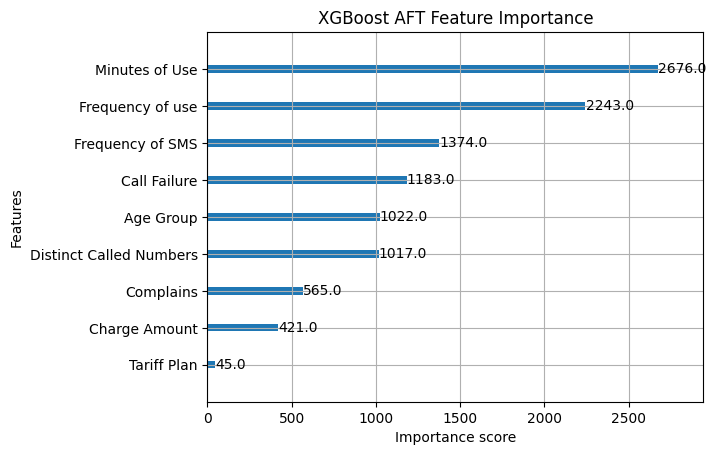

In [28]:
plt.figure(figsize=(10, 6))
xgb.plot_importance(
    xgb_model, 
    max_num_features=10, 
    importance_type='weight',
    title='XGBoost AFT Feature Importance'
)
plt.show()

In [29]:
# To calculate IBS score, it requires a survival function
# Because XGBoost doesn't output one, but rather a single scalar value that represents the predicted time to churn
# Therefore, y_train, y_test, surv_probs, and time need to be found

y_train = np.array(
    list(zip(df_train['Churn'].astype(bool), df_train['Subscription Length'])),
    dtype=[('Status', '?'), ('Time', '<f8')]
)
y_test = np.array(
    list(zip(df_test['Churn'].astype(bool), df_test['Subscription Length'])),
    dtype=[('Status', '?'), ('Time', '<f8')]
)
# ? means bool, <f8 means 64-bit float

# min_time is defined bcs the first few months mostly all the customer haven't churned yet and ibs don't know what to do with it
min_time = df_test['Subscription Length'].min()
safe_min_t = int(np.ceil(min_time)) # ceil to ensure it's not outside the lower bound
# The 90th percentile is used to avoid the Kaplan-Meier math cliff (used before reaching the chaotic and noisy end of the dataset)
safe_max_t = np.percentile(df_test['Subscription Length'], 90)
safe_max_t = int(safe_max_t)
times = np.arange(safe_min_t, safe_max_t)

surv_prob = np.zeros((len(pred_times), len(times)))
for i, pred_time in enumerate(pred_times):
    surv_prob[i, :] = norm.sf(times, loc=pred_time, scale=1.5) # row is pred_time of customer, 
    # col is times (timeline for customer)
    # 1.5 is the most realistic scale for customer churn data

ibs = integrated_brier_score(y_train, y_test, surv_prob, times)
print(f"Integrated Brier Score (IBS): {ibs:.4f}")

Integrated Brier Score (IBS): 0.0381


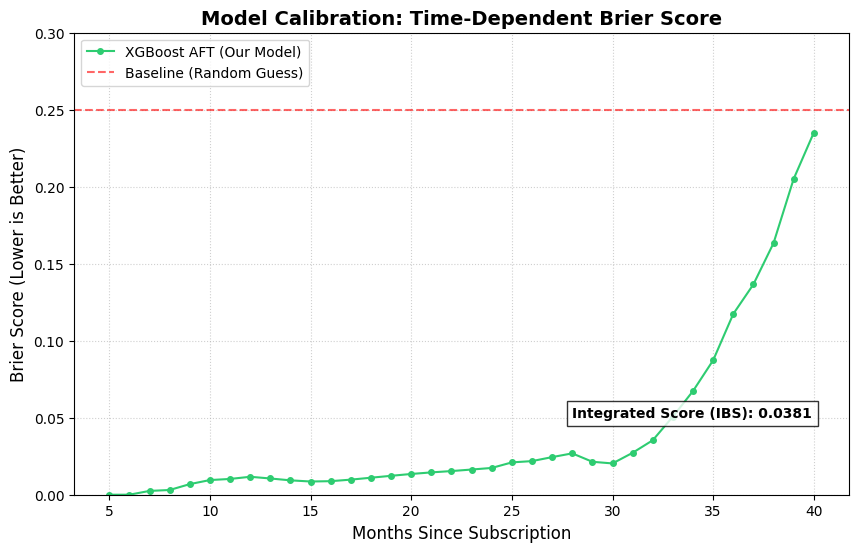

In [30]:
# calculate the raw brier scores for each point in the times grid
time_grid, brier_scores_array = brier_score(y_train, y_test, surv_prob, times)

plt.figure(figsize=(10, 6), dpi=100)
plt.plot(time_grid, brier_scores_array, color='#2ecc71', marker='o', markersize=4, label='XGBoost AFT (Our Model)')
plt.axhline(y=0.25, color='red', linestyle='--', alpha=0.6, label='Baseline (Random Guess)')

plt.title('Model Calibration: Time-Dependent Brier Score', fontsize=14, fontweight='bold')
plt.xlabel('Months Since Subscription', fontsize=12)
plt.ylabel('Brier Score (Lower is Better)', fontsize=12)
plt.ylim(0, 0.3) # 0.3 to show how far the guesses are from the 0.25 (random guess) line
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')

plt.text(time_grid.max()*0.7, 0.05, f'Integrated Score (IBS): {ibs:.4f}', 
         bbox=dict(facecolor='white', alpha=0.8), fontsize=10, fontweight='bold')

plt.show()

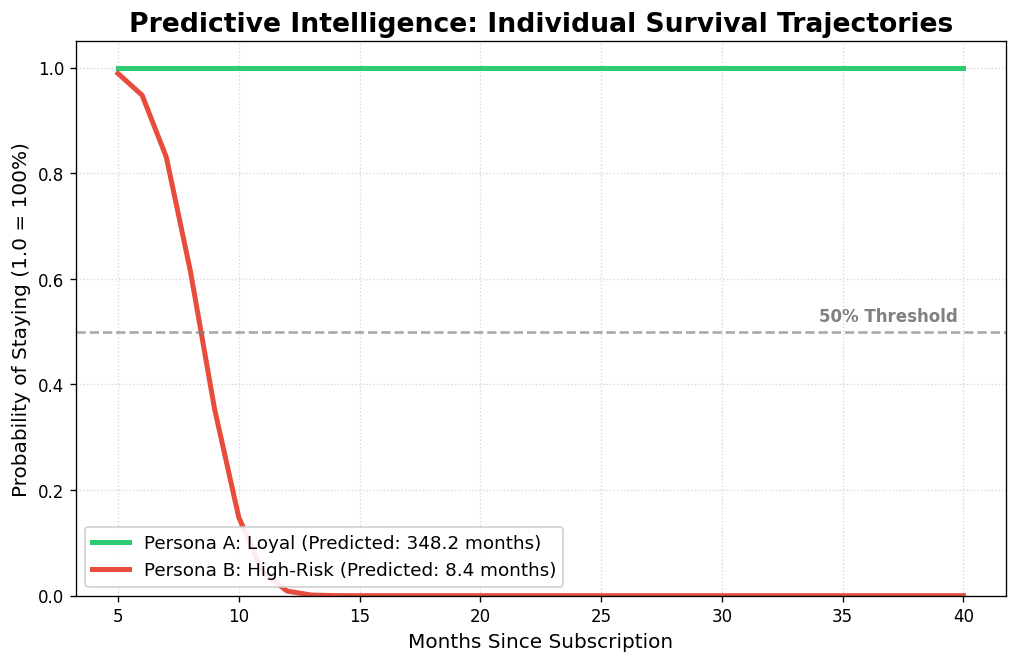

In [31]:
# How the model accurately seperates two extreme personas from each other (Survival Curve)

loyal_idx = np.argmin(-pred_times) 
risk_idx = np.argmax(-pred_times)

loyal_idx = np.argmax(pred_times)
risk_idx = np.argmin(pred_times)

plt.figure(figsize=(10, 6), dpi=120)

plt.plot(times, surv_prob[loyal_idx], color='#2ecc71', linewidth=3, 
         label=f'Persona A: Loyal (Predicted: {pred_times[loyal_idx]:.1f} months)')

plt.plot(times, surv_prob[risk_idx], color='#e74c3c', linewidth=3, 
         label=f'Persona B: High-Risk (Predicted: {pred_times[risk_idx]:.1f} months)')

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7)
plt.text(times.max()*0.85, 0.52, '50% Threshold', color='gray', fontweight='bold')

plt.title('Predictive Intelligence: Individual Survival Trajectories', fontsize=16, fontweight='bold')
plt.xlabel('Months Since Subscription', fontsize=12)
plt.ylabel('Probability of Staying (1.0 = 100%)', fontsize=12)
plt.ylim(0, 1.05)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower left', fontsize=11, framealpha=0.9)

plt.show()